<a href="https://colab.research.google.com/github/vidhusree/ML-Project/blob/main/Day6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [108]:
#unsupervised Learning

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [110]:
ur1=pd.read_csv("https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv")

In [111]:
ur1

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [112]:
ur1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


<Axes: >

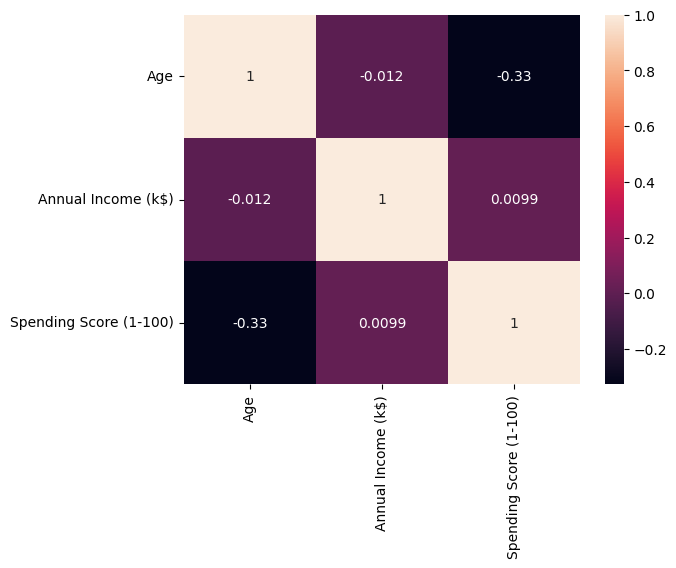

In [113]:
import seaborn as sns
data=ur1.drop(columns=['CustomerID','Gender'])
sns.heatmap(data.corr(),annot=True)

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

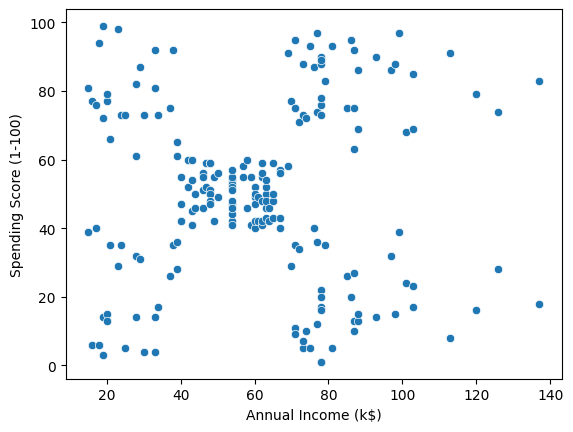

In [114]:
sns.scatterplot(data=ur1,x='Annual Income (k$)',y='Spending Score (1-100)')

In [115]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(data.drop(columns=['Age']))
x_scaled

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

In [116]:
#apply kmeans

In [117]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
WCSS=[]
sil_scores=[]
for k in range(2,11):
  kmeans=KMeans(n_clusters=k,
                init='k-means++',
                random_state=42,
                max_iter=300,
                n_init=10)
  kmeans.fit_predict(x_scaled)
  labels=kmeans.labels_
  WCSS.append(kmeans.inertia_)
  sil_h=silhouette_score(x_scaled,labels)
  sil_scores.append(sil_h)


In [118]:
for i ,k in enumerate(range(2,11)):
  print(f"for k={k},WCS={WCSS[i]:.2f} and sil_score={sil_scores[i]:.2f}")

for k=2,WCS=269.69 and sil_score=0.32
for k=3,WCS=157.70 and sil_score=0.47
for k=4,WCS=108.92 and sil_score=0.49
for k=5,WCS=65.57 and sil_score=0.55
for k=6,WCS=55.06 and sil_score=0.54
for k=7,WCS=44.86 and sil_score=0.53
for k=8,WCS=37.23 and sil_score=0.46
for k=9,WCS=32.39 and sil_score=0.46
for k=10,WCS=29.98 and sil_score=0.44


Text(0, 0.5, 'silhoette score')

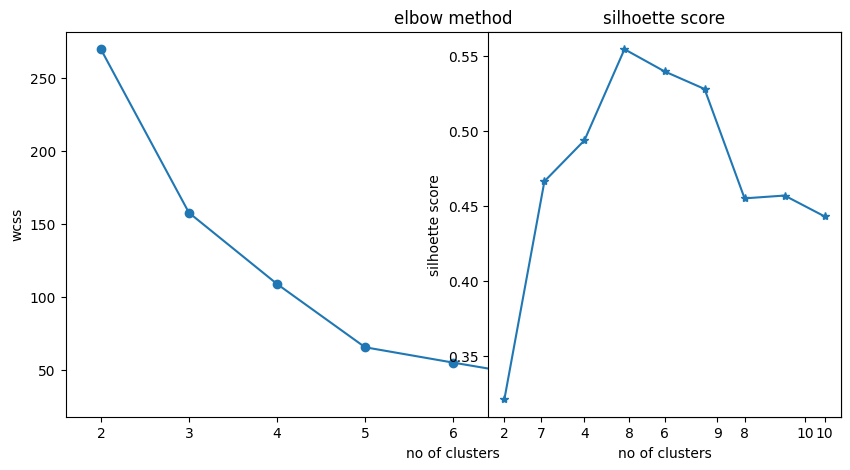

In [119]:
plt.figure(figsize=(10,5))
plt.plot(range(2,11),WCSS,marker='o')
plt.title("elbow method")
plt.xlabel("no of clusters")
plt.ylabel("wcss")

plt.subplot(1,2,2)
plt.plot(range(2,11),sil_scores,marker='*')
plt.title("silhoette score")
plt.xlabel("no of clusters")
plt.ylabel("silhoette score")

In [120]:
kmeans=KMeans(n_clusters=5,random_state=42,init='k-means++',max_iter=300,n_init=10)
kmeans.fit_predict(x_scaled)
cluster_labels=kmeans.labels_
cluster_labels

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [121]:
ur1['k_means_cluster']=cluster_labels
ur1

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),k_means_cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
...,...,...,...,...,...,...
195,196,Female,35,120,79,1
196,197,Female,45,126,28,3
197,198,Male,32,126,74,1
198,199,Male,32,137,18,3


In [122]:
ur1['k_means_cluster'].value_counts()

,count
k_means_cluster,
0,81
1,39
3,35
4,23
2,22


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

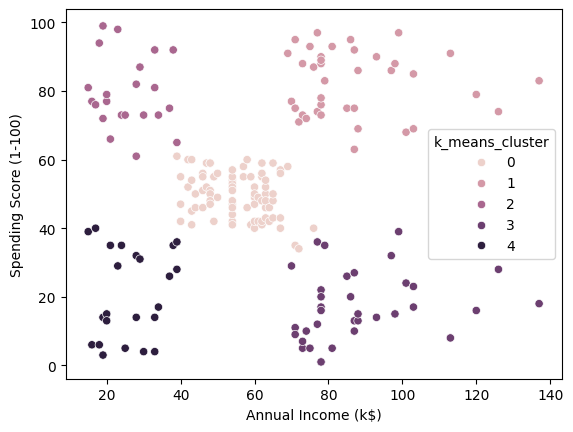

In [123]:
sns.scatterplot(data=ur1,x='Annual Income (k$)',y='Spending Score (1-100)',hue='k_means_cluster')

In [124]:
new_customer=np.array([[45,60]])
scaled=scaler.transform(new_customer)
cluster=kmeans.predict(scaled)
cluster

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([0], dtype=int32)

In [125]:
#Hierarchial clustering

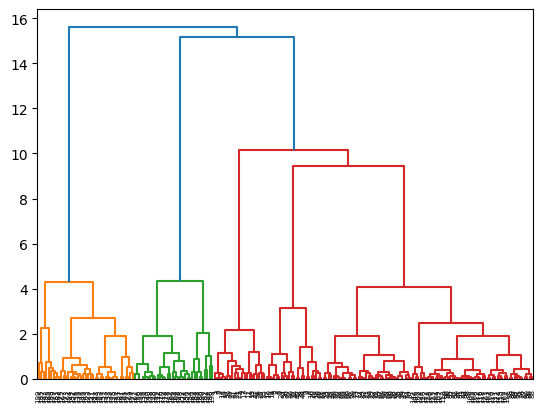

In [126]:
from scipy.cluster.hierarchy import dendrogram, linkage
mergings = linkage(x_scaled, method="ward")
dendrogram(mergings)
plt.show()




In [127]:
from sklearn.cluster import AgglomerativeClustering
agg_hc = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
agg_cluster=agg_hc.fit_predict(x_scaled)
agg_cluster

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 2,
       4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 1, 0, 1, 0, 1,
       2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1])

In [128]:
ur1['agg_cluster']=agg_cluster
ur1.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),k_means_cluster,agg_cluster
0,1,Male,19,15,39,4,4
1,2,Male,21,15,81,2,3
2,3,Female,20,16,6,4,4
3,4,Female,23,16,77,2,3
4,5,Female,31,17,40,4,4


In [129]:
ur1.k_means_cluster.value_counts()

,count
k_means_cluster,
0,81
1,39
3,35
4,23
2,22


In [130]:
ur1['agg_cluster'].value_counts()

,count
agg_cluster,
2,85
1,39
0,32
4,23
3,21


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

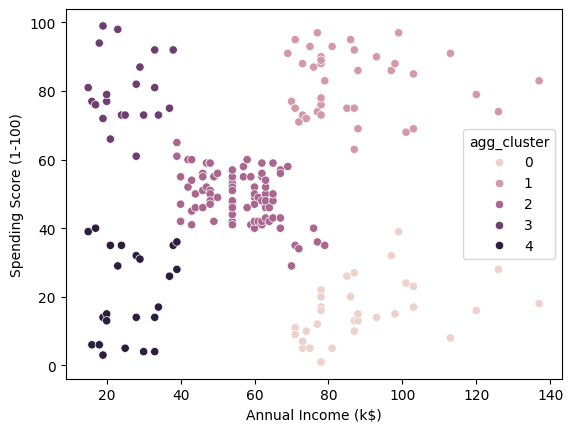

In [131]:
sns.scatterplot(data=ur1,x='Annual Income (k$)',y='Spending Score (1-100)',hue='agg_cluster')

In [132]:
sil_scores={}
for i in range(2,11):
  agg_hc=AgglomerativeClustering(n_clusters=i,metric='euclidean',linkage='ward')
  agg_cluster=agg_hc.fit_predict(x_scaled,agg_hc.fit_predict(x_scaled))
  sil_score=silhouette_score(x_scaled,agg_cluster)
  sil_scores[i]=sil_score
sil_scores

{2: np.float64(0.3842337621772661),
 3: np.float64(0.4610481446570447),
 4: np.float64(0.4925507715349343),
 5: np.float64(0.5538089226688662),
 6: np.float64(0.5386761871036926),
 7: np.float64(0.5197949293475768),
 8: np.float64(0.4308617778221774),
 9: np.float64(0.43768997758154127),
 10: np.float64(0.4339007174968657)}

In [133]:
from sklearn.cluster import DBSCAN

In [134]:
db = DBSCAN(eps=0.5, min_samples=5)
labels = db.fit_predict(x_scaled)
print(labels)

[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1
  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1
  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0 -1
 -1  1 -1 -1 -1 -1 -1 -1]


In [135]:
ur1['db_cluster']=labels
ur1

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),k_means_cluster,agg_cluster,db_cluster
0,1,Male,19,15,39,4,4,0
1,2,Male,21,15,81,2,3,0
2,3,Female,20,16,6,4,4,0
3,4,Female,23,16,77,2,3,0
4,5,Female,31,17,40,4,4,0
...,...,...,...,...,...,...,...,...
195,196,Female,35,120,79,1,1,-1
196,197,Female,45,126,28,3,0,-1
197,198,Male,32,126,74,1,1,-1
198,199,Male,32,137,18,3,0,-1


In [136]:
ur1['db_cluster'].value_counts()

,count
db_cluster,
0,157
1,35
-1,8


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

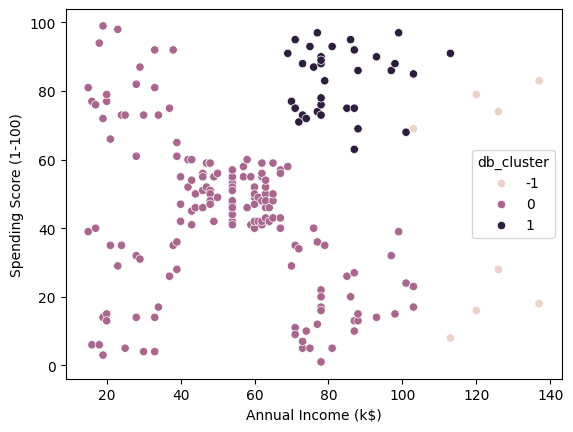

In [137]:
sns.scatterplot(data=ur1,x='Annual Income (k$)',y='Spending Score (1-100)',hue='db_cluster')

In [138]:
sil_scores={}
for i in range(2,11):
  agg_hc=DBSCAN(metric='euclidean')
  agg_cluster=agg_hc.fit_predict(x_scaled,agg_hc.fit_predict(x_scaled))
  sil_score=silhouette_score(x_scaled,agg_cluster)
  sil_scores[i]=sil_score
sil_scores

{2: np.float64(0.35044619989666004),
 3: np.float64(0.35044619989666004),
 4: np.float64(0.35044619989666004),
 5: np.float64(0.35044619989666004),
 6: np.float64(0.35044619989666004),
 7: np.float64(0.35044619989666004),
 8: np.float64(0.35044619989666004),
 9: np.float64(0.35044619989666004),
 10: np.float64(0.35044619989666004)}

In [139]:
from scipy.cluster.hierarchy import fcluster
cluster_labels=fcluster(mergings,t=5,criterion='maxclust')
cluster_labels

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 5,
       4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 1, 5, 1, 5, 1, 2, 1, 2, 1,
       5, 1, 2, 1, 2, 1, 2, 1, 2, 1, 5, 1, 2, 1, 5, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 5, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1], dtype=int32)

In [140]:
###  AN ###

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [142]:
df=pd.read_csv("/content/fish.csv")

In [143]:
df.columns=['species','weight','length1','length2','length3','height','width']
df

,species,weight,length1,length2,length3,height,width
0,Bream,290.0,24.0,26.3,31.2,40.0,13.8
1,Bream,340.0,23.9,26.5,31.1,39.8,15.1
2,Bream,363.0,26.3,29.0,33.5,38.0,13.3
3,Bream,430.0,26.5,29.0,34.0,36.6,15.1
4,Bream,450.0,26.8,29.7,34.7,39.2,14.2
...,...,...,...,...,...,...,...
79,Pike,950.0,48.3,51.7,55.1,16.2,11.2
80,Pike,1250.0,52.0,56.0,59.7,17.9,11.7
81,Pike,1600.0,56.0,60.0,64.0,15.0,9.6
82,Pike,1550.0,56.0,60.0,64.0,15.0,9.6


In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   species  84 non-null     object 
 1   weight   84 non-null     float64
 2   length1  84 non-null     float64
 3   length2  84 non-null     float64
 4   length3  84 non-null     float64
 5   height   84 non-null     float64
 6   width    84 non-null     float64
dtypes: float64(6), object(1)
memory usage: 4.7+ KB


<Axes: >

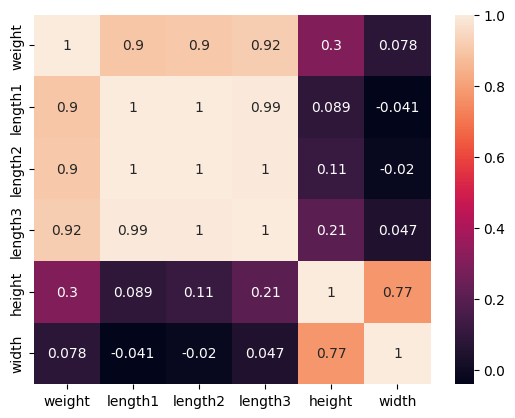

In [145]:
import seaborn as sns
data=df.drop(columns=['species'])
sns.heatmap(data.corr(),annot=True)

<Axes: xlabel='length1', ylabel='weight'>

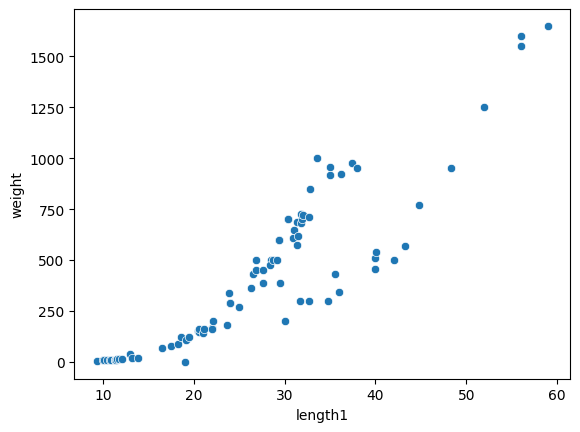

In [146]:
sns.scatterplot(data=df,x='length1',y='weight')

In [147]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(data)
x_scaled

array([[-0.37863149, -0.30035487, -0.2716005 , -0.14834877,  1.1707675 ,
         0.44432002],
       [-0.24717853, -0.30921988, -0.25517542, -0.15592863,  1.15132991,
         1.05849403],
       [-0.18671016, -0.09645972, -0.04986186,  0.02598811,  0.97639163,
         0.20809925],
       [-0.01056318, -0.0787297 , -0.04986186,  0.06388743,  0.84032853,
         1.05849403],
       [ 0.042018  , -0.05213468,  0.00762593,  0.11694647,  1.09301715,
         0.63329664],
       [ 0.17347097, -0.05213468,  0.00762593,  0.10178675,  1.27767423,
         1.15298234],
       [-0.11572556,  0.01878537,  0.03226356,  0.13968607,  0.80145335,
         0.25534341],
       [ 0.042018  ,  0.01878537,  0.03226356,  0.14726593,  1.16104871,
         0.44432002],
       [ 0.17347097,  0.09857043,  0.08975135,  0.23064443,  1.10273595,
         0.39707587],
       [ 0.10774449,  0.08970542,  0.11438898,  0.23064443,  1.11245474,
         0.58605249],
       [ 0.17347097,  0.11630044,  0.11438898,  0.

In [148]:
# kmeans

In [149]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
WCSS=[]
sil_scores=[]
for k in range(2,11):
  kmeans=KMeans(n_clusters=k,
                init='k-means++',
                random_state=42,
                max_iter=300,
                n_init=10)
  kmeans.fit_predict(x_scaled)
  labels=kmeans.labels_
  WCSS.append(kmeans.inertia_)
  sil_h=silhouette_score(x_scaled,labels)
  sil_scores.append(sil_h)


In [150]:
for i ,k in enumerate(range(2,11)):
  print(f"for k={k},WCSS={WCSS[i]:.2f} and sil_score={sil_scores[i]:.2f}")

for k=2,WCSS=280.89 and sil_score=0.42
for k=3,WCSS=152.52 and sil_score=0.52
for k=4,WCSS=95.64 and sil_score=0.57
for k=5,WCSS=50.03 and sil_score=0.61
for k=6,WCSS=37.64 and sil_score=0.53
for k=7,WCSS=31.31 and sil_score=0.51
for k=8,WCSS=26.62 and sil_score=0.50
for k=9,WCSS=22.88 and sil_score=0.45
for k=10,WCSS=19.87 and sil_score=0.45


Text(0, 0.5, 'silhoette score')

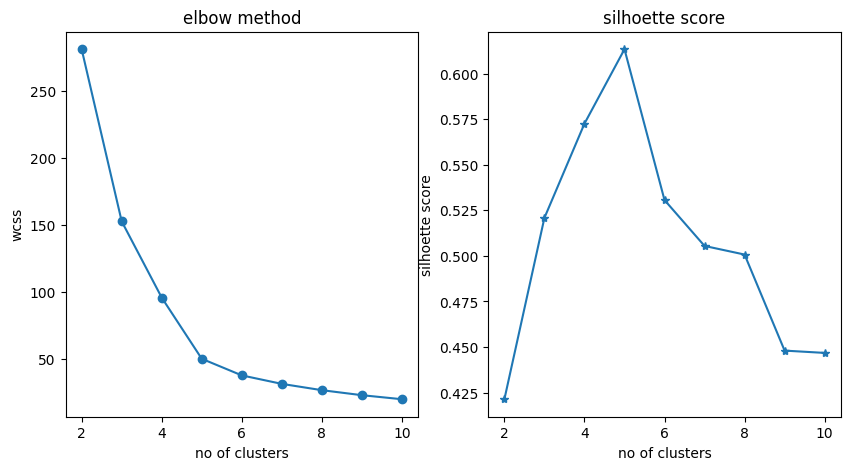

In [151]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(range(2,11),WCSS,marker='o')
plt.title("elbow method")
plt.xlabel("no of clusters")
plt.ylabel("wcss")

plt.subplot(1,2,2)
plt.plot(range(2,11),sil_scores,marker='*')
plt.title("silhoette score")
plt.xlabel("no of clusters")
plt.ylabel("silhoette score")

In [152]:
kmeans=KMeans(n_clusters=5,random_state=42,init='k-means++',max_iter=300,n_init=10)
kmeans.fit_predict(x_scaled)
cluster_labels=kmeans.labels_
cluster_labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1,
       3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 4], dtype=int32)

In [153]:
data['k_means_cluster']=cluster_labels
data

,weight,length1,length2,length3,height,width,k_means_cluster
0,290.0,24.0,26.3,31.2,40.0,13.8,0
1,340.0,23.9,26.5,31.1,39.8,15.1,0
2,363.0,26.3,29.0,33.5,38.0,13.3,0
3,430.0,26.5,29.0,34.0,36.6,15.1,0
4,450.0,26.8,29.7,34.7,39.2,14.2,0
...,...,...,...,...,...,...,...
79,950.0,48.3,51.7,55.1,16.2,11.2,4
80,1250.0,52.0,56.0,59.7,17.9,11.7,4
81,1600.0,56.0,60.0,64.0,15.0,9.6,4
82,1550.0,56.0,60.0,64.0,15.0,9.6,4


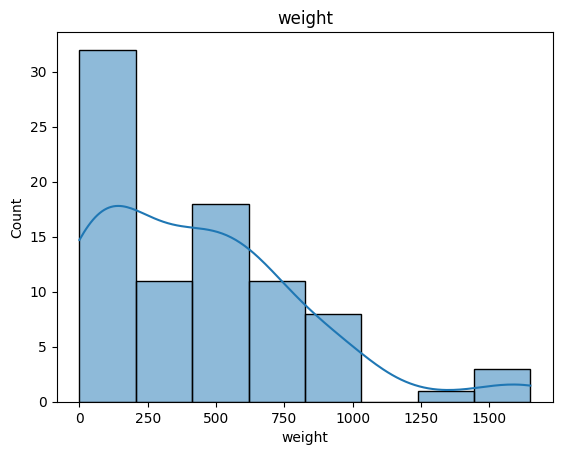

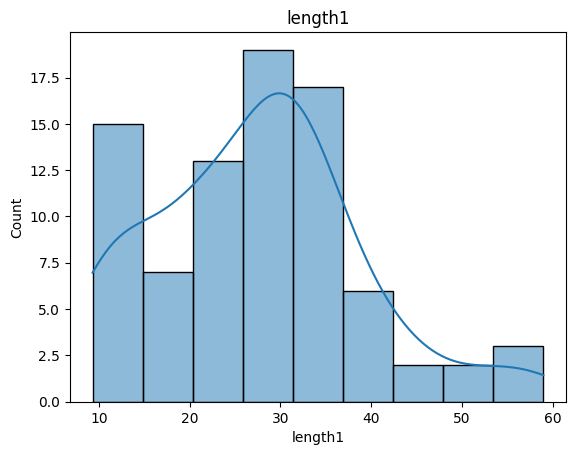

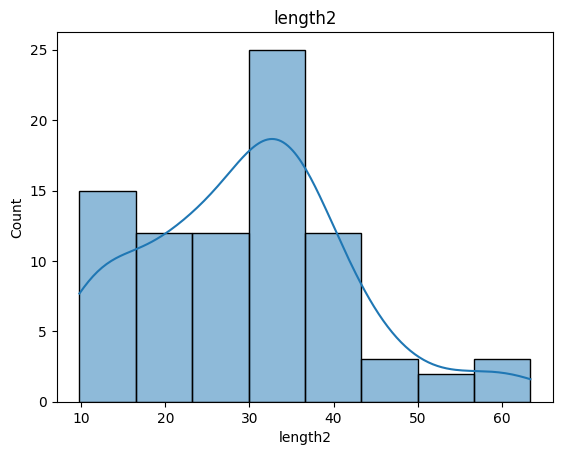

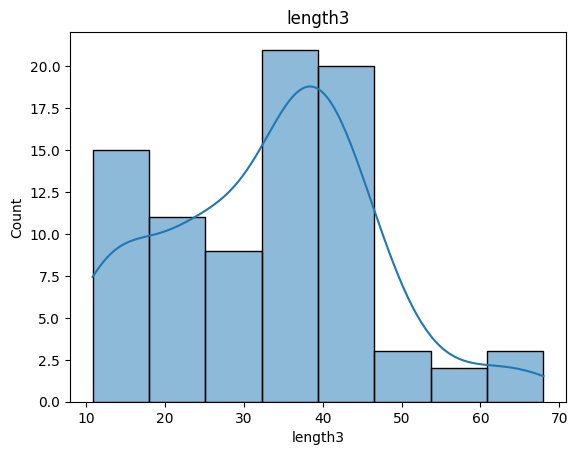

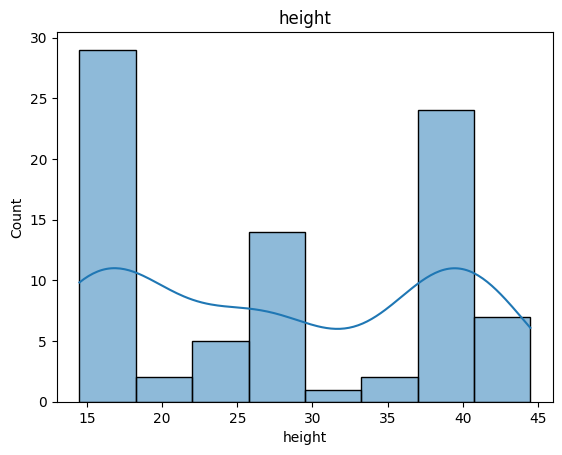

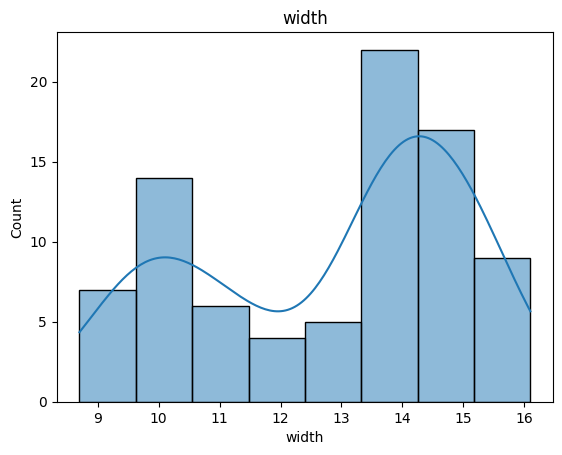

In [154]:
num_col=df.select_dtypes(include=np.number).columns
num_col
for col in num_col:
  sns.histplot(df[col],kde=True)
  plt.title(col)
  plt.show()

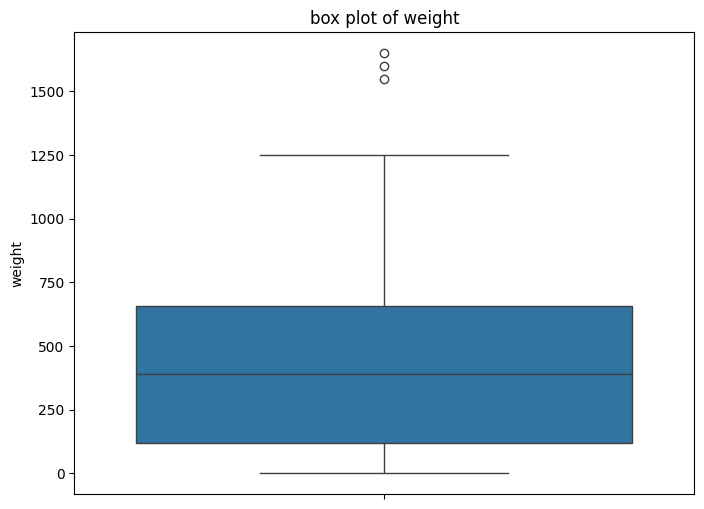

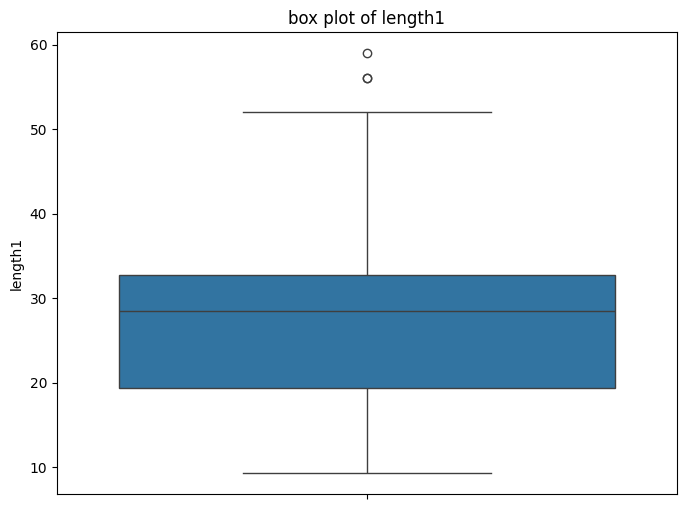

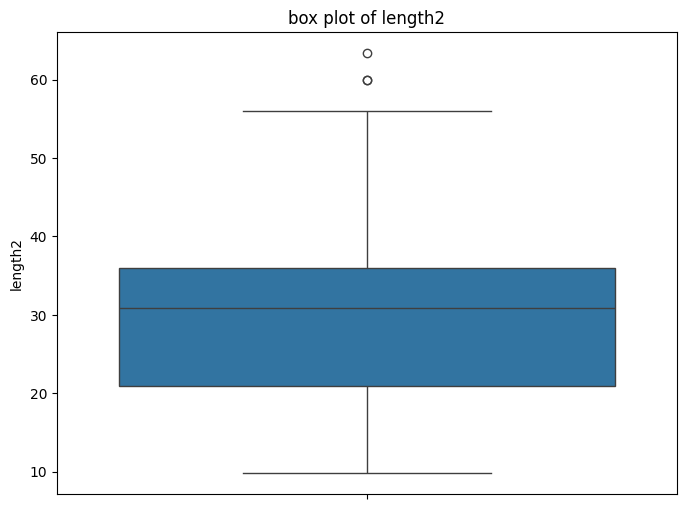

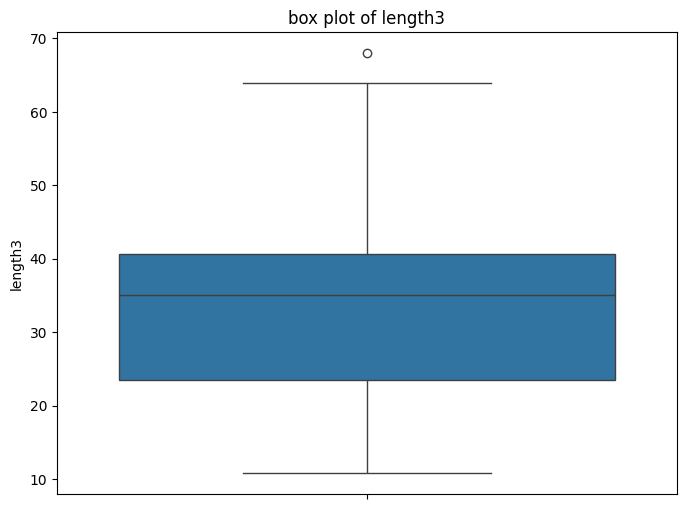

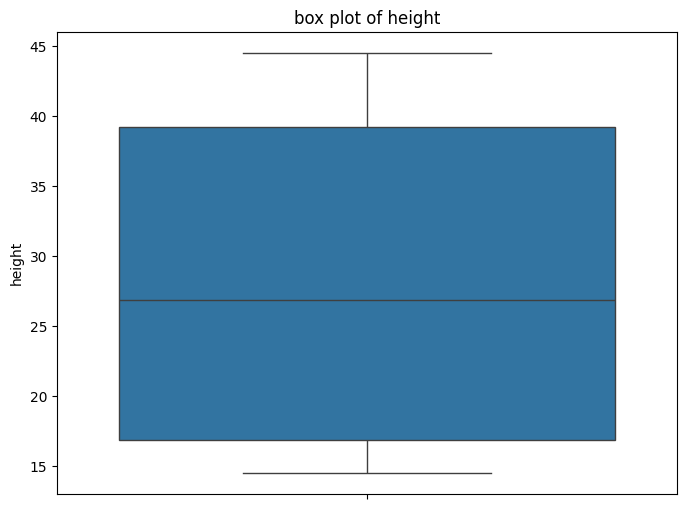

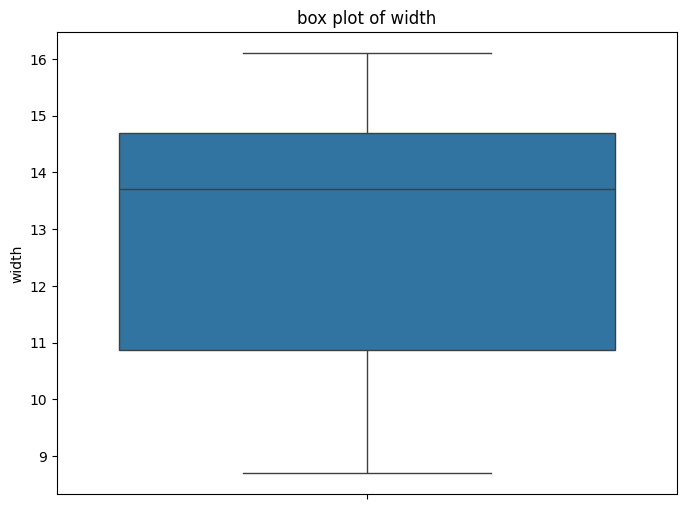

In [155]:
numerical_cols=df.select_dtypes(include=np.number).columns
for col in numerical_cols:
  plt.figure(figsize=(8,6))
  sns.boxplot(y=df[col])
  plt.title(f'box plot of {col}')
  plt.show()



In [156]:
from scipy.stats.mstats import winsorize
df['weight']=winsorize(df['weight'],limits=(0.05,0.05))
df.head()

,species,weight,length1,length2,length3,height,width
0,Bream,290.0,24.0,26.3,31.2,40.0,13.8
1,Bream,340.0,23.9,26.5,31.1,39.8,15.1
2,Bream,363.0,26.3,29.0,33.5,38.0,13.3
3,Bream,430.0,26.5,29.0,34.0,36.6,15.1
4,Bream,450.0,26.8,29.7,34.7,39.2,14.2


In [159]:
data['k_means_cluster'].value_counts()

,count
k_means_cluster,
0,34
1,20
3,13
2,12
4,5


In [160]:
#heirarchical clustering

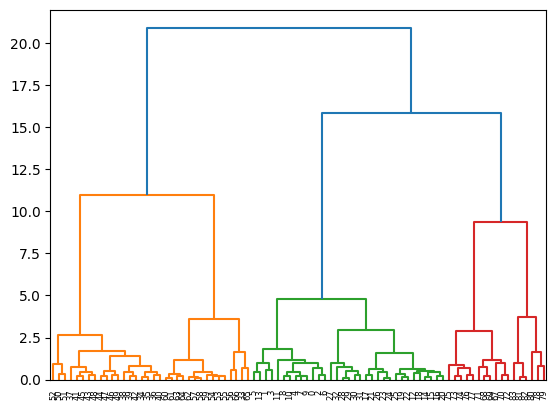

In [161]:
from scipy.cluster.hierarchy import dendrogram, linkage
mergings = linkage(x_scaled, method="ward")
dendrogram(mergings)
plt.show()


In [162]:
from sklearn.cluster import AgglomerativeClustering
agg_hc = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
agg_cluster=agg_hc.fit_predict(x_scaled)
agg_cluster

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 2, 2, 2, 2, 2, 2])

In [163]:
from scipy.cluster.hierarchy import fcluster
cluster_labels=fcluster(mergings,4,criterion='maxclust')
cluster_labels

array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4], dtype=int32)

In [164]:
df['agg_cluster']=agg_cluster
df.head()


,species,weight,length1,length2,length3,height,width,agg_cluster
0,Bream,290.0,24.0,26.3,31.2,40.0,13.8,0
1,Bream,340.0,23.9,26.5,31.1,39.8,15.1,0
2,Bream,363.0,26.3,29.0,33.5,38.0,13.3,0
3,Bream,430.0,26.5,29.0,34.0,36.6,15.1,0
4,Bream,450.0,26.8,29.7,34.7,39.2,14.2,0


In [165]:
df['agg_cluster'].value_counts()

,count
agg_cluster,
0,33
3,19
1,15
4,11
2,6


In [169]:
data['k_means_cluster'].value_counts()

,count
k_means_cluster,
0,34
1,20
3,13
2,12
4,5


<Axes: xlabel='weight', ylabel='length1'>

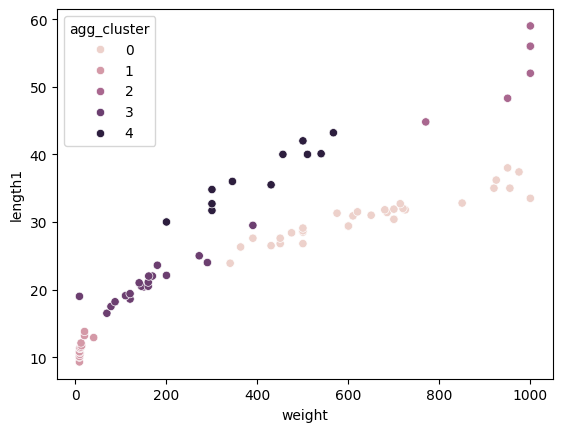

In [170]:
sns.scatterplot(data=df,x='weight',y='length1',hue='agg_cluster')

In [171]:
sil_scores={}
for i in range(2,11):
  agg_hc=AgglomerativeClustering(n_clusters=i,metric='euclidean',linkage='ward')
  sil_h=silhouette_score(x_scaled,agg_hc.fit_predict(x_scaled))
  sil_scores[i]=sil_h
sil_scores


{2: np.float64(0.4145080144933428),
 3: np.float64(0.511730107492879),
 4: np.float64(0.5465520404406123),
 5: np.float64(0.580437586628707),
 6: np.float64(0.49769191018862036),
 7: np.float64(0.490192410339021),
 8: np.float64(0.4665934938924753),
 9: np.float64(0.4644330100024386),
 10: np.float64(0.4541055703695885)}

In [172]:
from sklearn.cluster import DBSCAN
db_cluster=DBSCAN(eps=0.5,min_samples=5)
db_cluster=db_cluster.fit_predict(x_scaled)
db_cluster


array([-1, -1,  0, -1,  0, -1,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  1,  1,  1,  1, -1, -1,
        2,  2,  2, -1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
       -1, -1,  3,  3,  3, -1,  3,  3,  3,  3,  3,  3,  3,  3, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [173]:
df['db_cluster']=db_cluster
df.head()


,species,weight,length1,length2,length3,height,width,agg_cluster,db_cluster
0,Bream,290.0,24.0,26.3,31.2,40.0,13.8,0,-1
1,Bream,340.0,23.9,26.5,31.1,39.8,15.1,0,-1
2,Bream,363.0,26.3,29.0,33.5,38.0,13.3,0,0
3,Bream,430.0,26.5,29.0,34.0,36.6,15.1,0,-1
4,Bream,450.0,26.8,29.7,34.7,39.2,14.2,0,0


<Axes: xlabel='weight', ylabel='length1'>

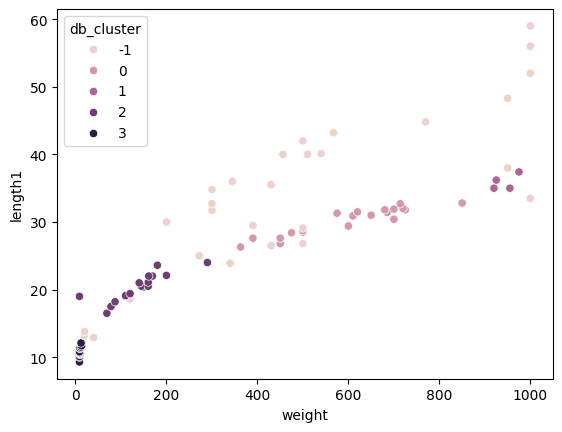

In [174]:
sns.scatterplot(data=df,x='weight',y='length1',hue='db_cluster')

In [175]:
sil_scores={}
for i in range(2,11):
  db_hc=DBSCAN(eps=0.5,min_samples=5)
  sil_h=silhouette_score(x_scaled,db_hc.fit_predict(x_scaled))
  sil_scores[i]=sil_h
sil_scores

{2: np.float64(0.2928990591178215),
 3: np.float64(0.2928990591178215),
 4: np.float64(0.2928990591178215),
 5: np.float64(0.2928990591178215),
 6: np.float64(0.2928990591178215),
 7: np.float64(0.2928990591178215),
 8: np.float64(0.2928990591178215),
 9: np.float64(0.2928990591178215),
 10: np.float64(0.2928990591178215)}